# 06 — When Does STL Decomposition Help?

**Research Question**: Under what conditions does STL decomposition improve forecasting accuracy, and which models benefit most?

## Narrative

STL (Seasonal-Trend decomposition via LOESS) pre-processes a time series into trend, seasonal, and remainder components before forecasting. Two variants are tested:
- **STL-SN** (`stl_seasonal_naive`): seasonal component replaced by seasonal naïve, model forecasts trend+remainder only
- **STL-AC** (`stl_model_all_components`): model forecasts all three STL components separately and sums
- **Direct** (`without_stl`): model forecasts the raw series

This notebook:
1. Quantifies the unconditional STL effect by model family
2. Identifies models where STL *always* helps / hurts with statistical confidence (Wilcoxon + Holm)
3. Maps how each time-series feature regime (Low/Medium/High) modulates the STL benefit
4. Derives evidence-based routing rules: when to use STL-SN, STL-AC, or Direct
5. Produces publication-quality figures

**Metric**: `rel_naive_clipped` (RelNaive, lower = better, capped at 10). **STL delta** = Direct RelNaive − STL RelNaive; positive = STL helps.

In [1]:
from __future__ import annotations
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

DATA = Path('data')
FIG  = DATA
FIG.mkdir(exist_ok=True)

# ── colour palette ──────────────────────────────────────────────────────────
FAM_COLORS = {
    'statistical':    '#2166ac',
    'mlforecast':     '#4dac26',
    'neuralforecast': '#d01c8b',
    'transformers':   '#f1a340',
}
DECOMP_COLORS = {
    'without_stl':              '#555555',
    'stl_seasonal_naive':       '#e66101',
    'stl_model_all_components': '#5e3c99',
}
DECOMP_LABELS = {
    'without_stl':              'Direct',
    'stl_seasonal_naive':       'STL-SN',
    'stl_model_all_components': 'STL-AC',
}
FAM_ORDER = ['statistical', 'mlforecast', 'neuralforecast', 'transformers']
FAM_LABELS = {'statistical': 'Statistical', 'mlforecast': 'ML', 'neuralforecast': 'Neural', 'transformers': 'Transformers'}
FEATURE_LABELS = {
    'feature_non_normality':           'Non-Normality',
    'feature_nonlinearity':            'Nonlinearity',
    'feature_spectral_entropy':        'Spectral Entropy',
    'feature_evolving_seasonality':    'Evolving Seasonality',
    'feature_structural_break_strength': 'Structural Break',
    'feature_arch_stat':               'ARCH Stat',
}
BUCKET_ORDER  = ['Low', 'Medium', 'High']
BUCKET_COLORS = {'Low': '#2166ac', 'Medium': '#fee090', 'High': '#d73027'}

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})
print('imports ok')

imports ok


In [2]:
mm  = pd.read_parquet(DATA / 'master_metrics.parquet')
std = pd.read_parquet(DATA / 'stl_delta.parquet')

# filter to no_finetune for clean comparisons (finetune_by_feature_bucket is statistically
# identical to no_finetune for statistical models; tiny constant multiplier for ML/Neural)
base = std[std['finetuning_mode'] == 'no_finetune'].copy()

print(f'master_metrics: {mm.shape}  |  stl_delta (no_finetune): {base.shape}')
print('decomp values :', base['decomposition_method'].unique().tolist())
print('families      :', base['model_family'].unique().tolist())

master_metrics: (3382722, 31)  |  stl_delta (no_finetune): (1288656, 35)
decomp values : ['stl_seasonal_naive', 'stl_model_all_components']
families      : ['statistical', 'mlforecast', 'neuralforecast', 'transformers']


---
## 1  Unconditional STL Effect by Model Family

In [3]:
# Mean RelNaive by family × decomp (raw series, not delta)
raw_mean = (
    mm[mm['finetuning_mode'] == 'no_finetune']
    .groupby(['model_family', 'decomposition_method'])['rel_naive_clipped']
    .mean()
    .reset_index()
)
raw_mean['decomp_label'] = raw_mean['decomposition_method'].map(DECOMP_LABELS)
raw_mean['fam_label']    = raw_mean['model_family'].map(FAM_LABELS)

pivot = raw_mean.pivot(index='model_family', columns='decomp_label', values='rel_naive_clipped')
pivot = pivot.loc[FAM_ORDER, ['Direct', 'STL-SN', 'STL-AC']]
pivot.index = [FAM_LABELS[f] for f in pivot.index]
print('Mean RelNaive by family × decomposition (lower = better):')
print(pivot.round(4).to_string())

# best decomp per family
pivot['Best'] = pivot.idxmin(axis=1)
print()
print(pivot[['Best']].to_string())

Mean RelNaive by family × decomposition (lower = better):
decomp_label  Direct  STL-SN  STL-AC
Statistical   0.9234  0.9321  0.9514
ML            1.0016  1.1959  1.1927
Neural        1.0024  1.1112  1.1210
Transformers  0.9972  0.9346  0.9587

decomp_label    Best
Statistical   Direct
ML            Direct
Neural        Direct
Transformers  STL-SN


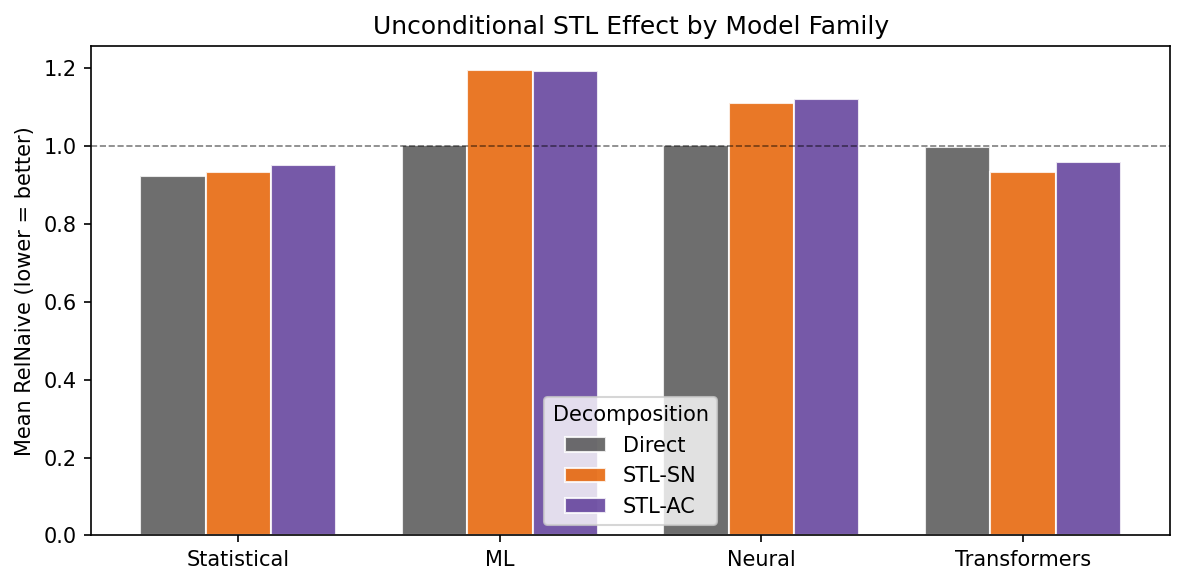

saved fig_overall_decomp.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(FAM_ORDER))
width = 0.25
for i, (dc, dlabel) in enumerate(DECOMP_LABELS.items()):
    vals = []
    for fam in FAM_ORDER:
        row = raw_mean[(raw_mean['model_family'] == fam) & (raw_mean['decomposition_method'] == dc)]
        vals.append(row['rel_naive_clipped'].values[0] if len(row) else np.nan)
    bars = ax.bar(x + (i - 1) * width, vals, width, label=dlabel,
                  color=DECOMP_COLORS[dc], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([FAM_LABELS[f] for f in FAM_ORDER])
ax.set_ylabel('Mean RelNaive (lower = better)')
ax.set_title('Unconditional STL Effect by Model Family')
ax.legend(title='Decomposition')
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
fig.tight_layout()
fig.savefig(FIG / 'fig_overall_decomp.png', dpi=150)
plt.show()
print('saved fig_overall_decomp.png')

---
## 2  Model-Level Confidence Analysis — "Always Helps / Always Hurts"

For each (model, decomp) pair we run a **Wilcoxon signed-rank test** on the per-series STL deltas (Direct − STL), then apply **Holm–Bonferroni correction** across all hypotheses. A model is classified as:
- **Always Helps**: significant positive mean delta (STL is better)
- **Always Hurts**: significant negative mean delta (STL is worse)
- **Mixed**: not significant

In [5]:
rows = []
for (fam, model, decomp), g in base.groupby(['model_family', 'model_name', 'decomposition_method']):
    d = g['rn_delta'].dropna()
    if len(d) < 10:
        continue
    try:
        stat, p = wilcoxon(d, alternative='two-sided')
    except Exception:
        p = 1.0
    rows.append({
        'model_family': fam,
        'model_name':   model,
        'decomposition_method': decomp,
        'n':            len(d),
        'mean_delta':   float(d.mean()),
        'median_delta': float(d.median()),
        'pct_helped':   float((d > 0).mean()),
        'p_raw':        p,
    })

wdf = pd.DataFrame(rows)
reject, p_adj, _, _ = multipletests(wdf['p_raw'].values, method='holm')
wdf['p_adj']   = p_adj
wdf['sig']     = reject
wdf['verdict'] = 'Mixed'
wdf.loc[wdf['sig'] & (wdf['mean_delta'] > 0), 'verdict'] = 'Always Helps'
wdf.loc[wdf['sig'] & (wdf['mean_delta'] < 0), 'verdict'] = 'Always Hurts'
wdf['decomp_label'] = wdf['decomposition_method'].map(DECOMP_LABELS)
wdf['fam_label']    = wdf['model_family'].map(FAM_LABELS)

print('Verdict counts by decomp:')
print(wdf.groupby(['decomp_label', 'verdict']).size().unstack(fill_value=0).to_string())

Verdict counts by decomp:
verdict       Always Helps  Always Hurts
decomp_label                            
STL-AC                   8             4
STL-SN                   8             4


In [6]:
# Table: models with definitive verdicts on STL-SN
stl_sn = wdf[wdf['decomposition_method'] == 'stl_seasonal_naive'].copy()
decisive = stl_sn[stl_sn['verdict'] != 'Mixed'].sort_values('mean_delta', ascending=False)
decisive_show = decisive[['fam_label', 'model_name', 'mean_delta', 'pct_helped', 'p_adj', 'verdict']].copy()
decisive_show.columns = ['Family', 'Model', 'Mean Δ RelNaive', '% Helped', 'p (Holm)', 'Verdict']
decisive_show['Mean Δ RelNaive'] = decisive_show['Mean Δ RelNaive'].round(4)
decisive_show['% Helped'] = (decisive_show['% Helped'] * 100).round(1)
decisive_show['p (Holm)'] = decisive_show['p (Holm)'].apply(lambda x: f'{x:.2e}')
print('Models with significant STL-SN verdict (Wilcoxon + Holm):')
print(decisive_show.to_string(index=False))

Models with significant STL-SN verdict (Wilcoxon + Holm):
      Family                Model  Mean Δ RelNaive  % Helped  p (Holm)      Verdict
          ML            AutoRidge           0.0744      68.2  0.00e+00 Always Helps
          ML AutoLinearRegression           0.0733      68.5  0.00e+00 Always Helps
      Neural            AutoNHITS           0.0691      67.8  0.00e+00 Always Helps
      Neural          AutoNLinear           0.0674      68.2  0.00e+00 Always Helps
Transformers         AutoPatchTST           0.0654      68.3  0.00e+00 Always Helps
Transformers              AutoTFT           0.0599      67.6  0.00e+00 Always Helps
 Statistical            AutoARIMA           0.0104      38.9 3.70e-262 Always Helps
 Statistical           AutoSARIMA           0.0098      38.8 9.95e-276 Always Helps
 Statistical              AutoETS          -0.0464      33.5  0.00e+00 Always Hurts
          ML     AutoRandomForest          -0.4561      30.7  0.00e+00 Always Hurts
      Neural      

In [7]:
# Same for STL-AC
stl_ac = wdf[wdf['decomposition_method'] == 'stl_model_all_components'].copy()
decisive_ac = stl_ac[stl_ac['verdict'] != 'Mixed'].sort_values('mean_delta', ascending=False)
decisive_ac_show = decisive_ac[['fam_label', 'model_name', 'mean_delta', 'pct_helped', 'p_adj', 'verdict']].copy()
decisive_ac_show.columns = ['Family', 'Model', 'Mean Δ RelNaive', '% Helped', 'p (Holm)', 'Verdict']
decisive_ac_show['Mean Δ RelNaive'] = decisive_ac_show['Mean Δ RelNaive'].round(4)
decisive_ac_show['% Helped'] = (decisive_ac_show['% Helped'] * 100).round(1)
decisive_ac_show['p (Holm)'] = decisive_ac_show['p (Holm)'].apply(lambda x: f'{x:.2e}')
print('Models with significant STL-AC verdict (Wilcoxon + Holm):')
print(decisive_ac_show.to_string(index=False))

Models with significant STL-AC verdict (Wilcoxon + Holm):
      Family                Model  Mean Δ RelNaive  % Helped  p (Holm)      Verdict
          ML            AutoRidge           0.0697      70.5  0.00e+00 Always Helps
          ML AutoLinearRegression           0.0679      70.4  0.00e+00 Always Helps
Transformers         AutoPatchTST           0.0632      70.0  0.00e+00 Always Helps
      Neural          AutoNLinear           0.0614      70.1  0.00e+00 Always Helps
      Neural            AutoNHITS           0.0223      67.7  0.00e+00 Always Helps
Transformers              AutoTFT           0.0139      67.0  0.00e+00 Always Helps
 Statistical           AutoSARIMA           0.0034      42.1 2.28e-142 Always Helps
 Statistical            AutoARIMA           0.0032      42.2 4.89e-138 Always Helps
 Statistical              AutoETS          -0.0906      35.0  0.00e+00 Always Hurts
      Neural             AutoLSTM          -0.4395      34.8  0.00e+00 Always Hurts
          ML      

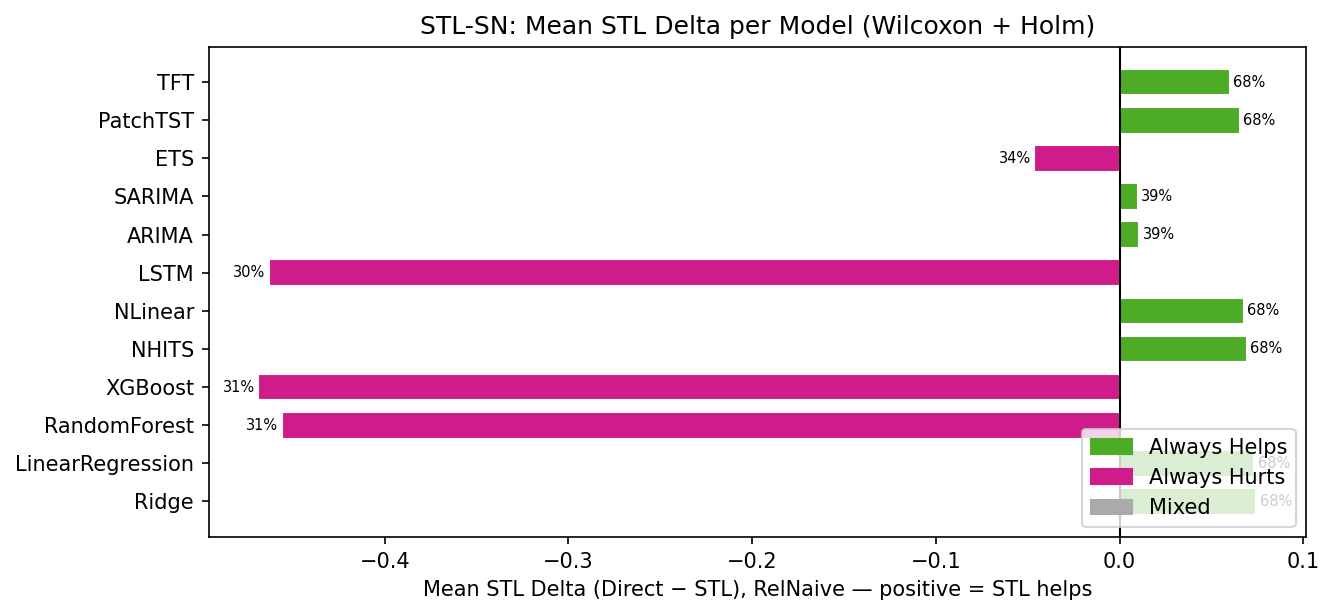

saved fig_sn_delta_tuned.png


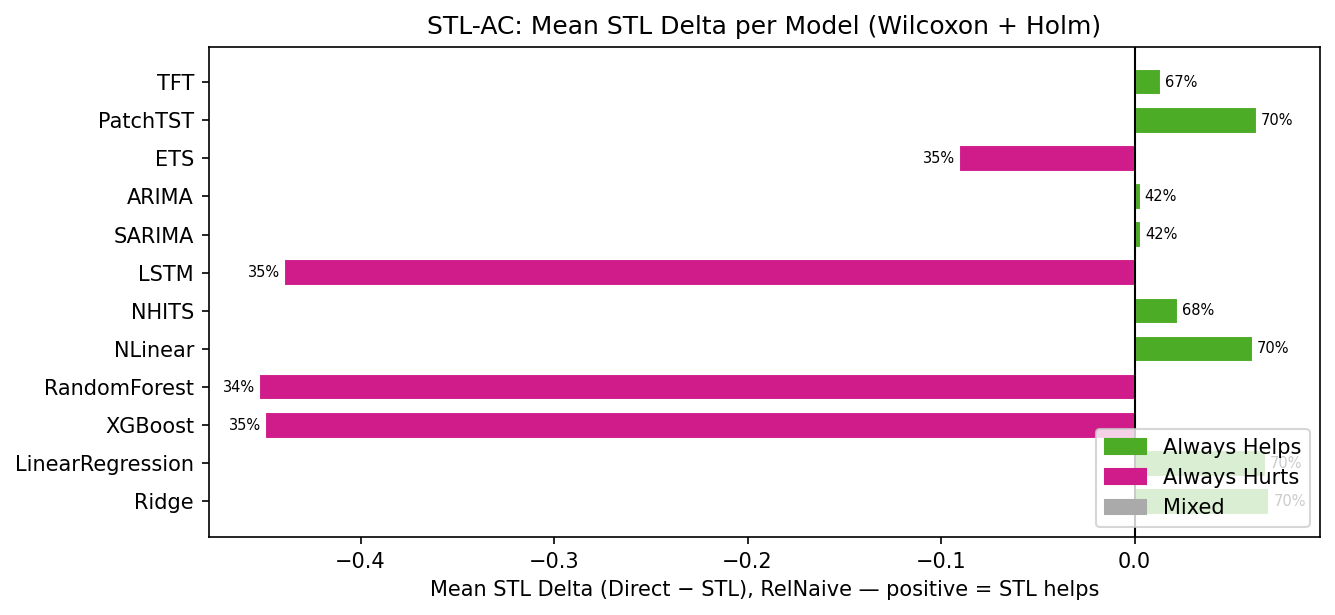

saved fig_ac_delta_tuned.png


In [8]:
# Figure: diverging bar chart of mean delta per model, coloured by verdict
for decomp_key, decomp_title in [('stl_seasonal_naive', 'STL-SN'), ('stl_model_all_components', 'STL-AC')]:
    sub = wdf[wdf['decomposition_method'] == decomp_key].copy()
    sub = sub.sort_values(['model_family', 'mean_delta'], ascending=[True, False])
    sub['label'] = sub['model_name'].str.replace('Auto', '', regex=False)

    palette = {'Always Helps': '#4dac26', 'Always Hurts': '#d01c8b', 'Mixed': '#aaaaaa'}
    colors  = sub['verdict'].map(palette)

    fig, ax = plt.subplots(figsize=(9, max(4, len(sub) * 0.35)))
    bars = ax.barh(sub['label'], sub['mean_delta'], color=colors, edgecolor='white', height=0.7)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('Mean STL Delta (Direct − STL), RelNaive — positive = STL helps')
    ax.set_title(f'{decomp_title}: Mean STL Delta per Model (Wilcoxon + Holm)')

    patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
    ax.legend(handles=patches, loc='lower right')

    # annotate pct_helped
    for _, row in sub.iterrows():
        ax.text(row['mean_delta'] + (0.002 if row['mean_delta'] >= 0 else -0.002),
                row['label'], f"{row['pct_helped']*100:.0f}%",
                va='center', ha='left' if row['mean_delta'] >= 0 else 'right', fontsize=7)

    fig.tight_layout()
    fname = f"fig_{'sn' if decomp_key == 'stl_seasonal_naive' else 'ac'}_delta_tuned.png"
    fig.savefig(FIG / fname, dpi=150)
    plt.show()
    print(f'saved {fname}')

---
## 3  Feature-Regime Conditional Analysis

For each of the 6 time-series features, we split series into Low/Medium/High terciles and compute mean STL delta per (family × bucket). This reveals *which regimes drive the STL benefit*.

In [9]:
stl_sn_delta = base[base['decomposition_method'] == 'stl_seasonal_naive'].copy()

feat_bucket = (
    stl_sn_delta
    .groupby(['feature_name', 'feature_bucket', 'model_family'])['rn_delta']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)
feat_bucket.columns = ['feature_name', 'feature_bucket', 'model_family', 'mean_delta', 'median_delta', 'n']

# pivot: feature × bucket, one column per family
for fam in FAM_ORDER:
    sub = feat_bucket[feat_bucket['model_family'] == fam]
    piv = sub.pivot(index='feature_name', columns='feature_bucket', values='mean_delta')[BUCKET_ORDER]
    piv.index = [FEATURE_LABELS.get(f, f) for f in piv.index]
    print(f'\n=== {FAM_LABELS[fam]} — STL-SN Mean Delta by Feature × Bucket ===')
    print(piv.round(4).to_string())


=== Statistical — STL-SN Mean Delta by Feature × Bucket ===
feature_bucket           Low  Medium    High
ARCH Stat            -0.0083  0.0070 -0.0186
Evolving Seasonality -0.0050 -0.0324 -0.0067
Non-Normality        -0.0066 -0.0213  0.0027
Nonlinearity         -0.0130     NaN  0.0052
Spectral Entropy      0.0100 -0.0153 -0.0145
Structural Break     -0.0159 -0.0257  0.0259

=== ML — STL-SN Mean Delta by Feature × Bucket ===
feature_bucket           Low  Medium    High
ARCH Stat            -0.1022 -0.1564 -0.3360
Evolving Seasonality -0.1481 -0.1970 -0.2378
Non-Normality        -0.1046 -0.1568 -0.3120
Nonlinearity         -0.2163     NaN -0.0601
Spectral Entropy     -0.3690 -0.1584 -0.0442
Structural Break     -0.1040 -0.2099 -0.2651

=== Neural — STL-SN Mean Delta by Feature × Bucket ===
feature_bucket           Low  Medium    High
ARCH Stat            -0.0466 -0.0729 -0.1919
Evolving Seasonality -0.0685 -0.1115 -0.1311
Non-Normality        -0.0490 -0.0861 -0.1960
Nonlinearity         

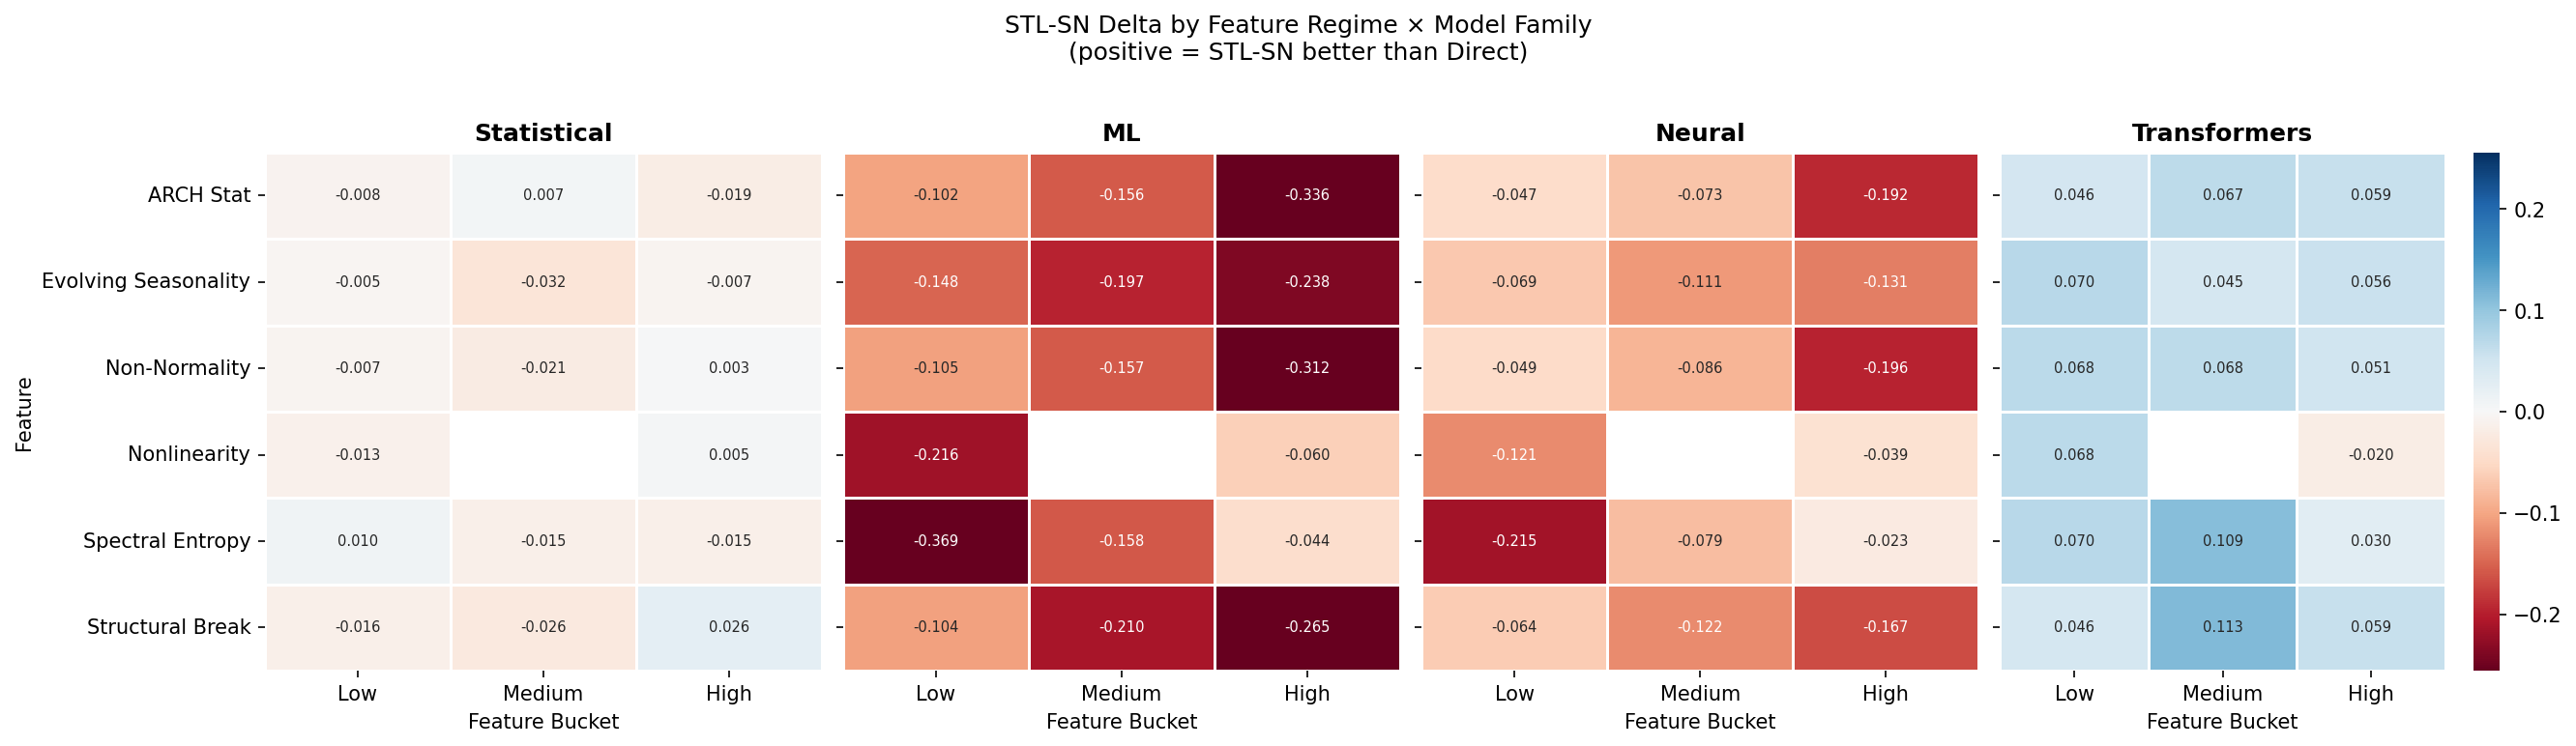

saved fig_family_stl_delta_heatmap.png


In [10]:
# Heatmap: feature × bucket for each family
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

for ax, fam in zip(axes, FAM_ORDER):
    sub = feat_bucket[feat_bucket['model_family'] == fam]
    piv = sub.pivot(index='feature_name', columns='feature_bucket', values='mean_delta')
    piv = piv.reindex(columns=BUCKET_ORDER)
    piv.index = [FEATURE_LABELS.get(f, f) for f in piv.index]

    vmax = feat_bucket['mean_delta'].abs().quantile(0.95)
    sns.heatmap(
        piv, ax=ax, center=0, vmin=-vmax, vmax=vmax,
        cmap='RdBu', linewidths=0.5, linecolor='white',
        annot=True, fmt='.3f', annot_kws={'size': 7},
        cbar=(ax is axes[-1]),
    )
    ax.set_title(FAM_LABELS[fam], fontweight='bold')
    ax.set_xlabel('Feature Bucket')
    if ax is axes[0]:
        ax.set_ylabel('Feature')
    else:
        ax.set_ylabel('')

fig.suptitle('STL-SN Delta by Feature Regime × Model Family\n(positive = STL-SN better than Direct)', y=1.02)
fig.tight_layout()
fig.savefig(FIG / 'fig_family_stl_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved fig_family_stl_delta_heatmap.png')

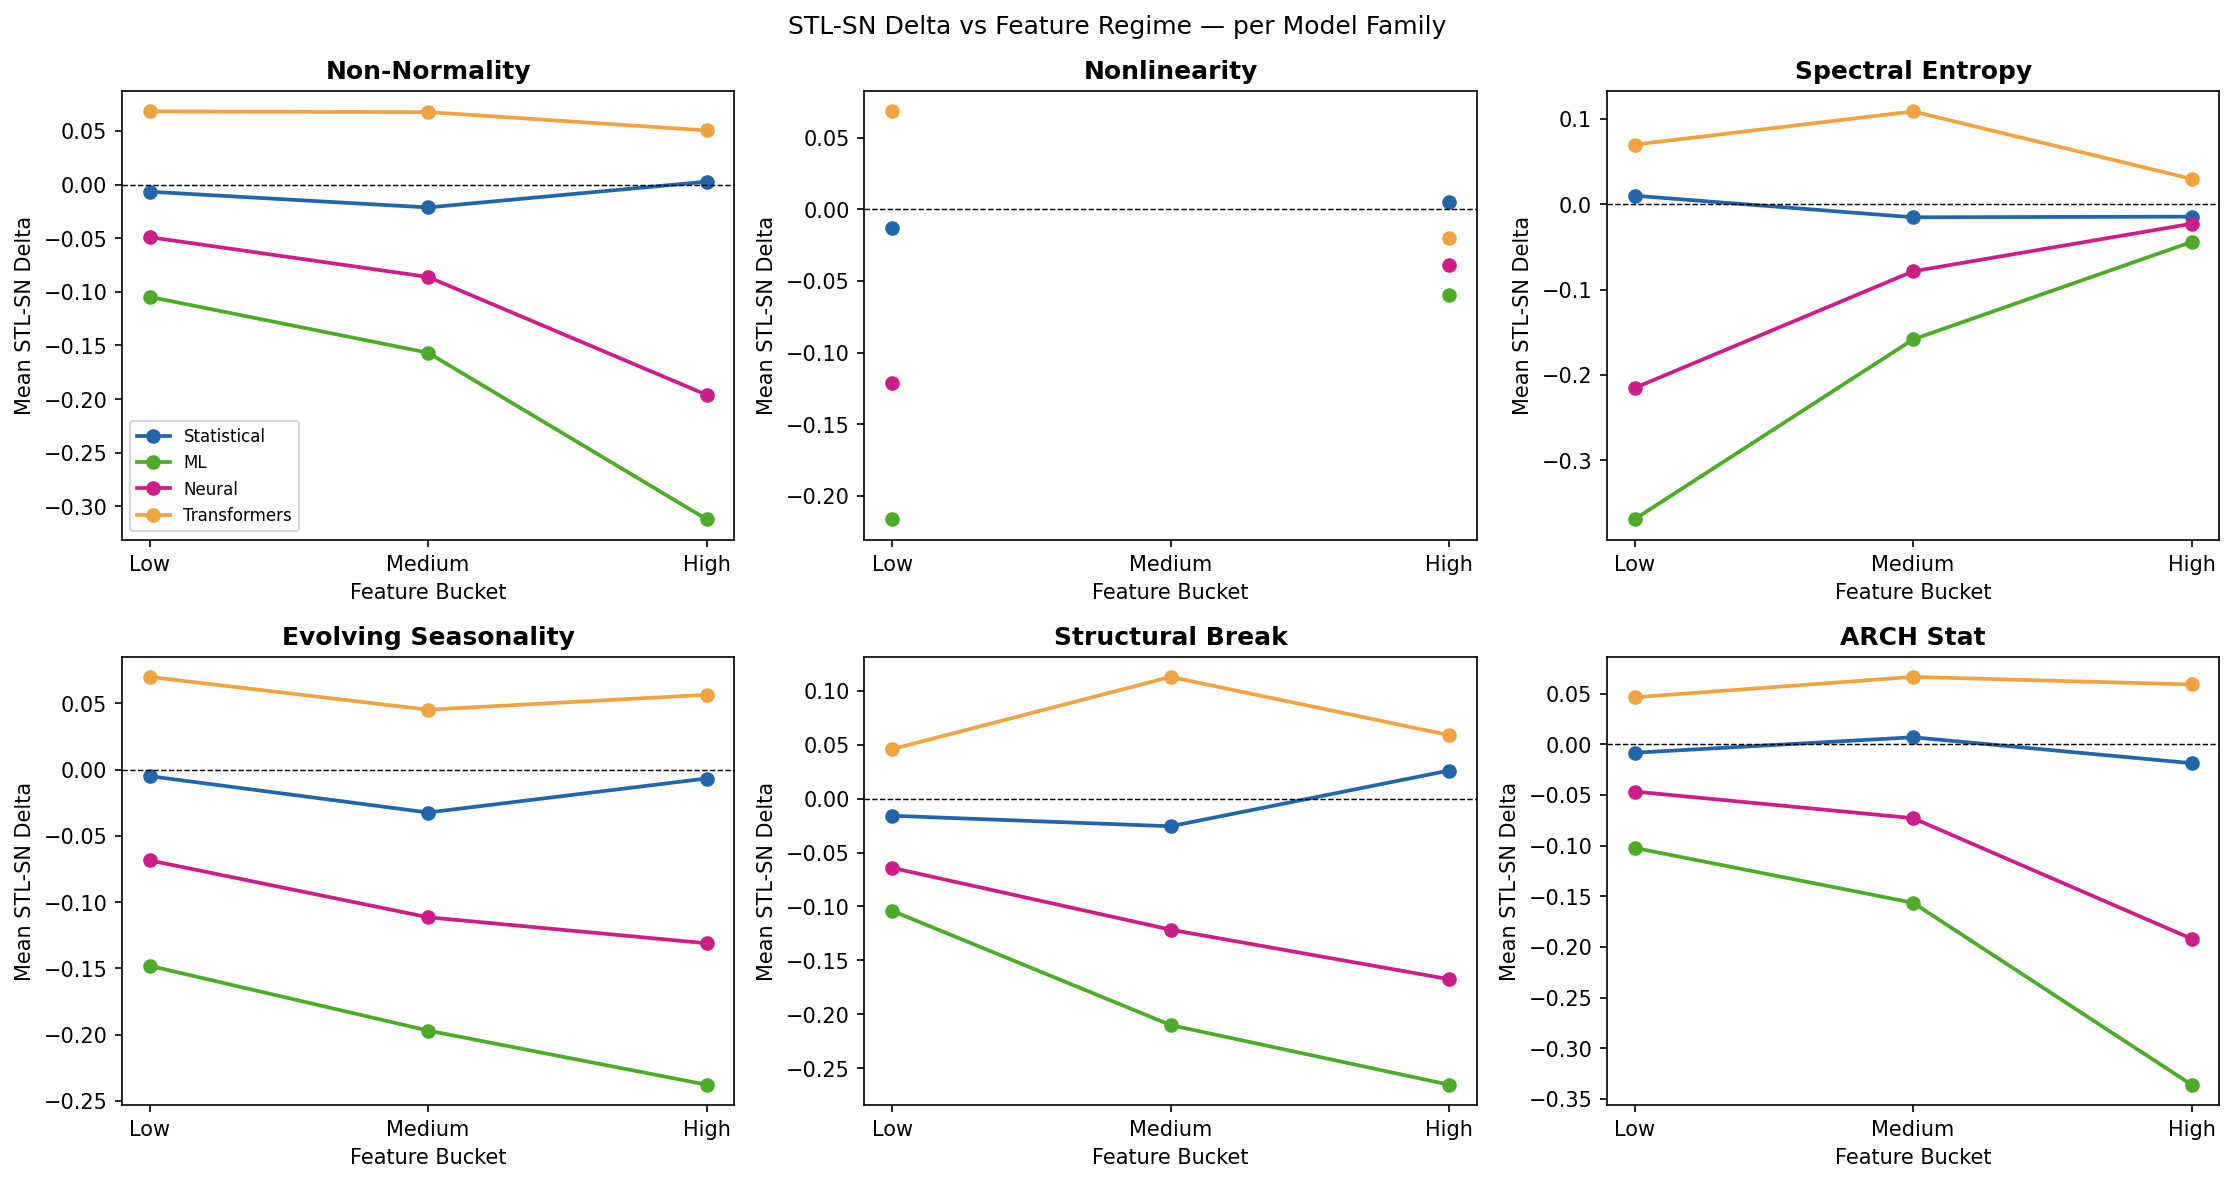

saved fig_feature_spread.png


In [11]:
# Per-feature line plots: bucket effect across families
features = list(FEATURE_LABELS.keys())
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feat in zip(axes.flat, features):
    sub = feat_bucket[feat_bucket['feature_name'] == feat]
    for fam in FAM_ORDER:
        fsub = sub[sub['model_family'] == fam].set_index('feature_bucket')['mean_delta']
        fsub = fsub.reindex(BUCKET_ORDER)
        ax.plot(BUCKET_ORDER, fsub.values, marker='o',
                color=FAM_COLORS[fam], label=FAM_LABELS[fam], linewidth=1.8)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(FEATURE_LABELS[feat], fontweight='bold')
    ax.set_xlabel('Feature Bucket')
    ax.set_ylabel('Mean STL-SN Delta')
    if feat == features[0]:
        ax.legend(fontsize=8)

fig.suptitle('STL-SN Delta vs Feature Regime — per Model Family', fontsize=12)
fig.tight_layout()
fig.savefig(FIG / 'fig_feature_spread.png', dpi=150)
plt.show()
print('saved fig_feature_spread.png')

---
## 4  Wilcoxon Significance per Feature × Bucket × Family (STL-SN)

In [12]:
rows2 = []
for (feat, bkt, fam), g in stl_sn_delta.groupby(['feature_name', 'feature_bucket', 'model_family']):
    d = g['rn_delta'].dropna()
    if len(d) < 10:
        continue
    try:
        _, p = wilcoxon(d, alternative='two-sided')
    except Exception:
        p = 1.0
    rows2.append({'feature_name': feat, 'feature_bucket': bkt,
                  'model_family': fam, 'n': len(d),
                  'mean_delta': float(d.mean()), 'p_raw': p})

wdf2 = pd.DataFrame(rows2)
reject2, p_adj2, _, _ = multipletests(wdf2['p_raw'].values, method='holm')
wdf2['p_adj'] = p_adj2
wdf2['sig']   = reject2
wdf2['verdict'] = 'Mixed'
wdf2.loc[wdf2['sig'] & (wdf2['mean_delta'] > 0), 'verdict'] = 'Always Helps'
wdf2.loc[wdf2['sig'] & (wdf2['mean_delta'] < 0), 'verdict'] = 'Always Hurts'
wdf2['feat_label'] = wdf2['feature_name'].map(FEATURE_LABELS)
wdf2['fam_label']  = wdf2['model_family'].map(FAM_LABELS)

# show only significant results
sig2 = wdf2[wdf2['sig']].sort_values(['feature_name', 'feature_bucket', 'model_family'])
sig2_show = sig2[['feat_label','feature_bucket','fam_label','mean_delta','n','p_adj','verdict']].copy()
sig2_show.columns = ['Feature','Bucket','Family','Mean Δ','N','p (Holm)','Verdict']
sig2_show['Mean Δ'] = sig2_show['Mean Δ'].round(4)
sig2_show['p (Holm)'] = sig2_show['p (Holm)'].apply(lambda x: f'{x:.2e}')
print(f'Significant conditions: {len(sig2)} of {len(wdf2)}')
print(sig2_show.to_string(index=False))

Significant conditions: 57 of 68
             Feature Bucket       Family  Mean Δ     N  p (Holm)      Verdict
           ARCH Stat   High           ML -0.3360 12000  3.86e-72 Always Hurts
           ARCH Stat   High  Statistical -0.0186  9000  1.33e-78 Always Hurts
           ARCH Stat   High Transformers  0.0591  6000 2.02e-170 Always Helps
           ARCH Stat    Low           ML -0.1022 11796  5.47e-16 Always Hurts
           ARCH Stat    Low       Neural -0.0466  8847  5.11e-05 Always Hurts
           ARCH Stat    Low  Statistical -0.0083  8847  8.38e-77 Always Hurts
           ARCH Stat    Low Transformers  0.0465  5898 8.53e-128 Always Helps
           ARCH Stat Medium           ML -0.1564 12000  2.64e-34 Always Hurts
           ARCH Stat Medium       Neural -0.0729  9000  5.23e-03 Always Hurts
           ARCH Stat Medium  Statistical  0.0070  9000  3.45e-62 Always Helps
           ARCH Stat Medium Transformers  0.0666  6000 1.78e-182 Always Helps
Evolving Seasonality   High    

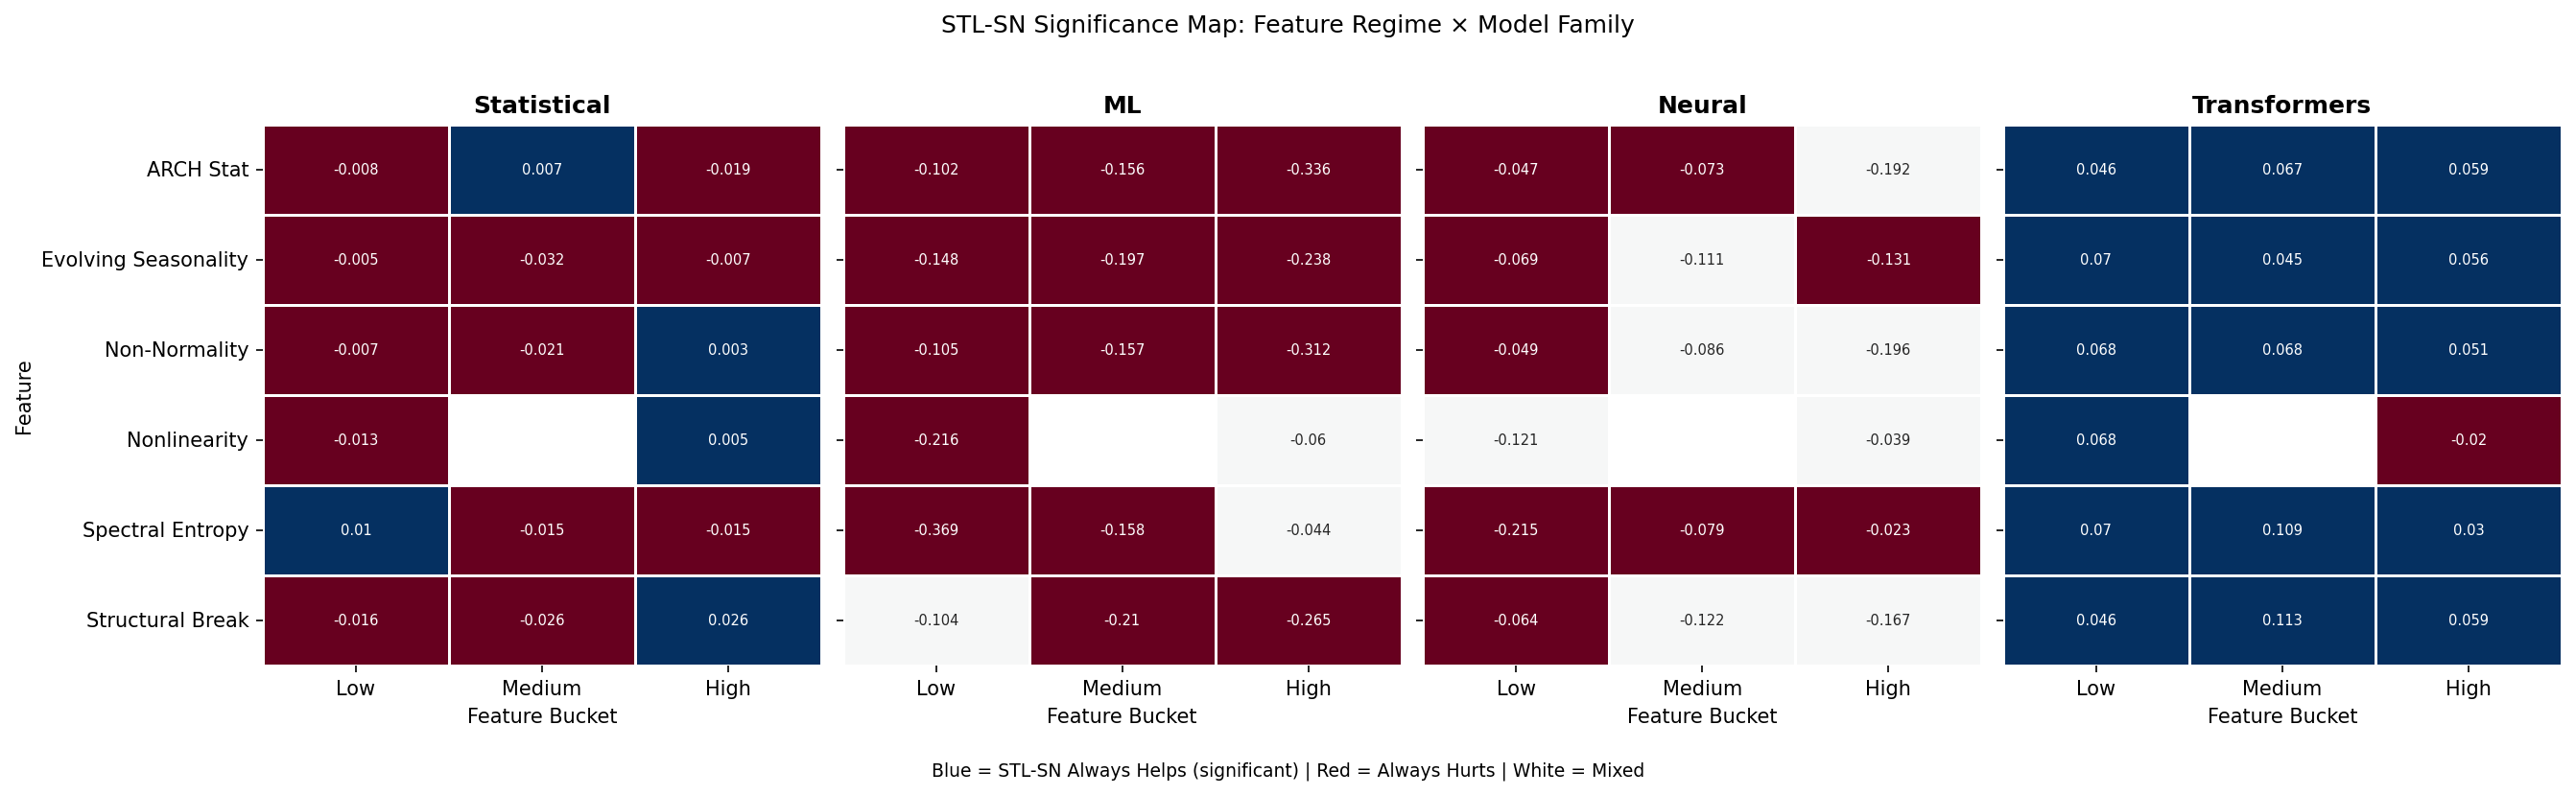

saved fig_freq_bucket_stl_significance.png


In [13]:
# Heatmap: significance map — feature×bucket conditions per family
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

verdict_num = {'Always Helps': 1, 'Mixed': 0, 'Always Hurts': -1}

for ax, fam in zip(axes, FAM_ORDER):
    sub2 = wdf2[wdf2['model_family'] == fam].copy()
    sub2['verdict_num'] = sub2['verdict'].map(verdict_num)
    piv2 = sub2.pivot(index='feature_name', columns='feature_bucket', values='verdict_num')
    piv2 = piv2.reindex(columns=BUCKET_ORDER)
    piv2.index = [FEATURE_LABELS.get(f, f) for f in piv2.index]

    # also show mean_delta as annotation
    piv_ann = sub2.pivot(index='feature_name', columns='feature_bucket', values='mean_delta')
    piv_ann = piv_ann.reindex(columns=BUCKET_ORDER)
    piv_ann.index = piv2.index

    sns.heatmap(
        piv2, ax=ax, vmin=-1, vmax=1,
        cmap='RdBu', linewidths=0.5, linecolor='white',
        annot=piv_ann.round(3), fmt='', annot_kws={'size': 7},
        cbar=False,
    )
    ax.set_title(FAM_LABELS[fam], fontweight='bold')
    ax.set_xlabel('Feature Bucket')
    ax.set_ylabel('' if ax is not axes[0] else 'Feature')

# legend
import matplotlib.cm as cm
fig.text(0.5, -0.04, 'Blue = STL-SN Always Helps (significant) | Red = Always Hurts | White = Mixed',
         ha='center', fontsize=9)
fig.suptitle('STL-SN Significance Map: Feature Regime × Model Family', fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(FIG / 'fig_freq_bucket_stl_significance.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved fig_freq_bucket_stl_significance.png')

---
## 5  Frequency Interaction — Monthly vs Quarterly

STL-SN Mean Delta by Frequency × Family:
frequency     monthly  quarterly
ML            -0.1662    -0.2227
Neural        -0.0901    -0.1278
Statistical   -0.0320     0.0149
Transformers   0.0514     0.0740


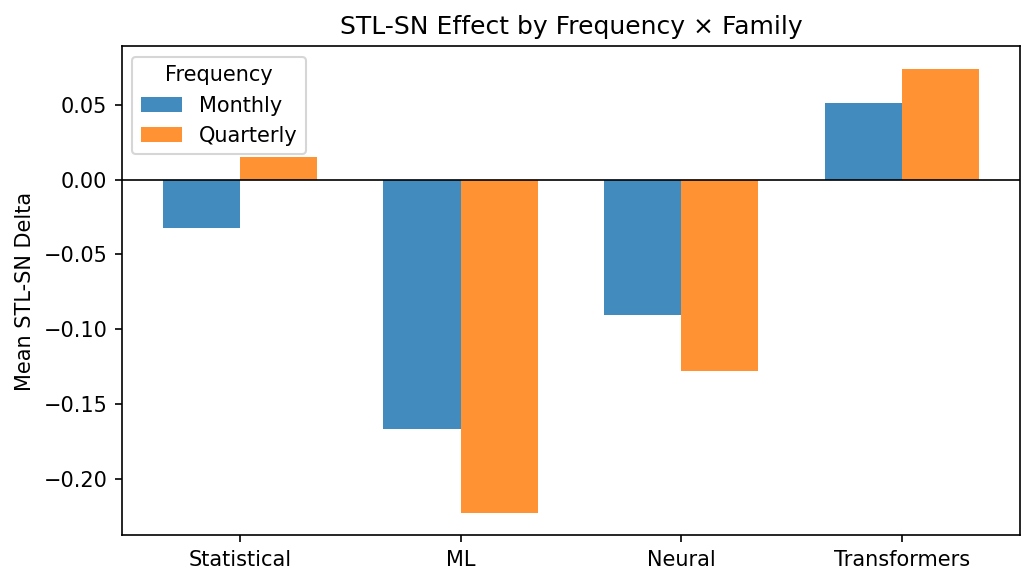

saved fig_freq_decomp.png


In [14]:
freq_fam = (
    base[base['decomposition_method'] == 'stl_seasonal_naive']
    .groupby(['frequency', 'model_family'])['rn_delta']
    .agg(['mean', 'count'])
    .reset_index()
)
freq_fam.columns = ['frequency', 'model_family', 'mean_delta', 'n']

piv_freq = freq_fam.pivot(index='model_family', columns='frequency', values='mean_delta')
piv_freq.index = [FAM_LABELS[f] for f in piv_freq.index]
print('STL-SN Mean Delta by Frequency × Family:')
print(piv_freq.round(4).to_string())

# grouped bar
freqs = piv_freq.columns.tolist()
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(FAM_ORDER))
w = 0.35
for i, freq in enumerate(freqs):
    vals = [piv_freq.loc[FAM_LABELS[fam], freq] if FAM_LABELS[fam] in piv_freq.index else np.nan
            for fam in FAM_ORDER]
    ax.bar(x + (i - 0.5) * w, vals, w, label=freq.capitalize(), alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([FAM_LABELS[f] for f in FAM_ORDER])
ax.set_ylabel('Mean STL-SN Delta')
ax.set_title('STL-SN Effect by Frequency × Family')
ax.legend(title='Frequency')
fig.tight_layout()
fig.savefig(FIG / 'fig_freq_decomp.png', dpi=150)
plt.show()
print('saved fig_freq_decomp.png')

---
## 6  POCID — Directional Accuracy of STL Decomposition

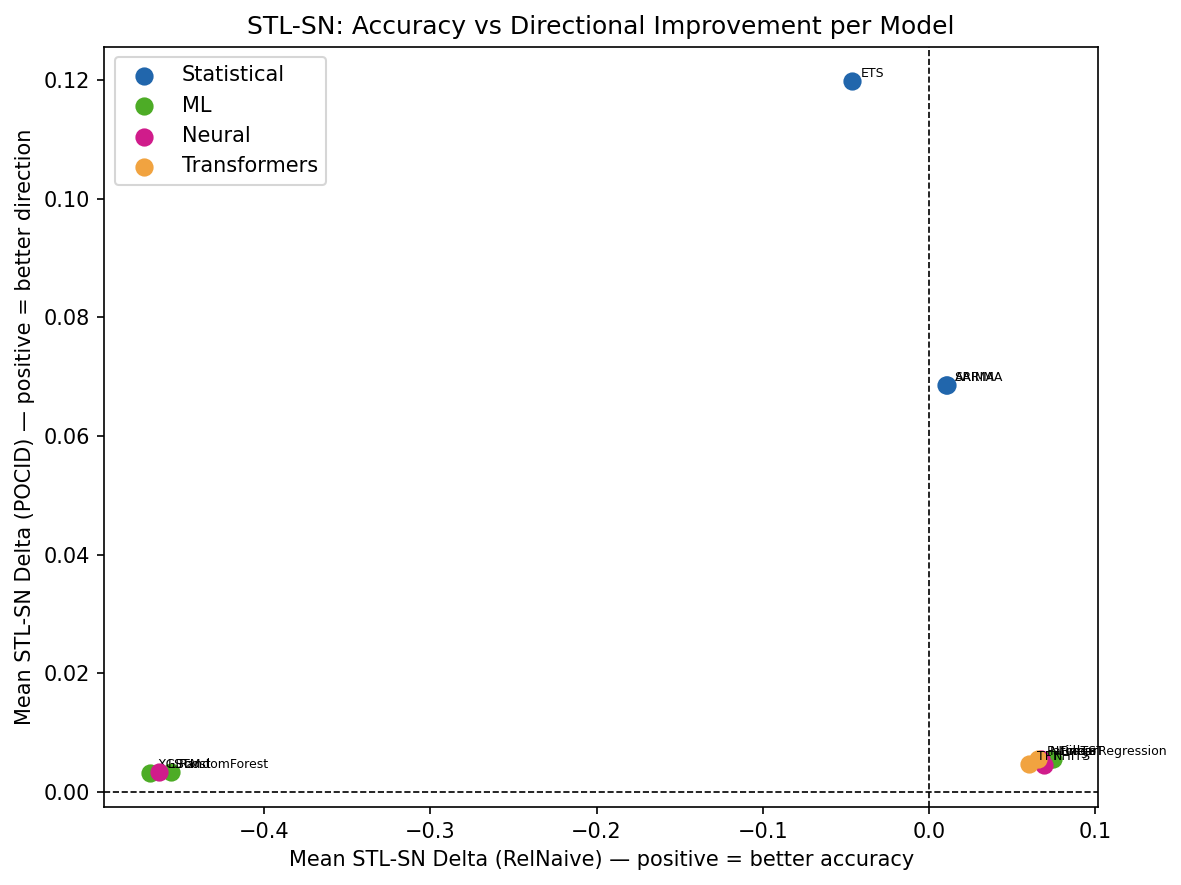

saved fig_pocid_tradeoff.png


In [15]:
# POCID delta: STL-SN vs Direct
pocid_fam = (
    base[base['decomposition_method'] == 'stl_seasonal_naive']
    .groupby('model_family')['pocid_delta']
    .agg(['mean', 'count'])
    .reset_index()
)
pocid_fam.columns = ['model_family', 'mean_pocid_delta', 'n']

# POCID vs RelNaive delta scatter per model
pocid_model = (
    base[base['decomposition_method'] == 'stl_seasonal_naive']
    .groupby(['model_family', 'model_name'])[['rn_delta', 'pocid_delta']]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 6))
for fam in FAM_ORDER:
    sub = pocid_model[pocid_model['model_family'] == fam]
    ax.scatter(sub['rn_delta'], sub['pocid_delta'],
               color=FAM_COLORS[fam], label=FAM_LABELS[fam], s=60, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['model_name'].replace('Auto', ''),
                    (row['rn_delta'], row['pocid_delta']),
                    fontsize=6, textcoords='offset points', xytext=(4, 2))

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean STL-SN Delta (RelNaive) — positive = better accuracy')
ax.set_ylabel('Mean STL-SN Delta (POCID) — positive = better direction')
ax.set_title('STL-SN: Accuracy vs Directional Improvement per Model')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'fig_pocid_tradeoff.png', dpi=150)
plt.show()
print('saved fig_pocid_tradeoff.png')

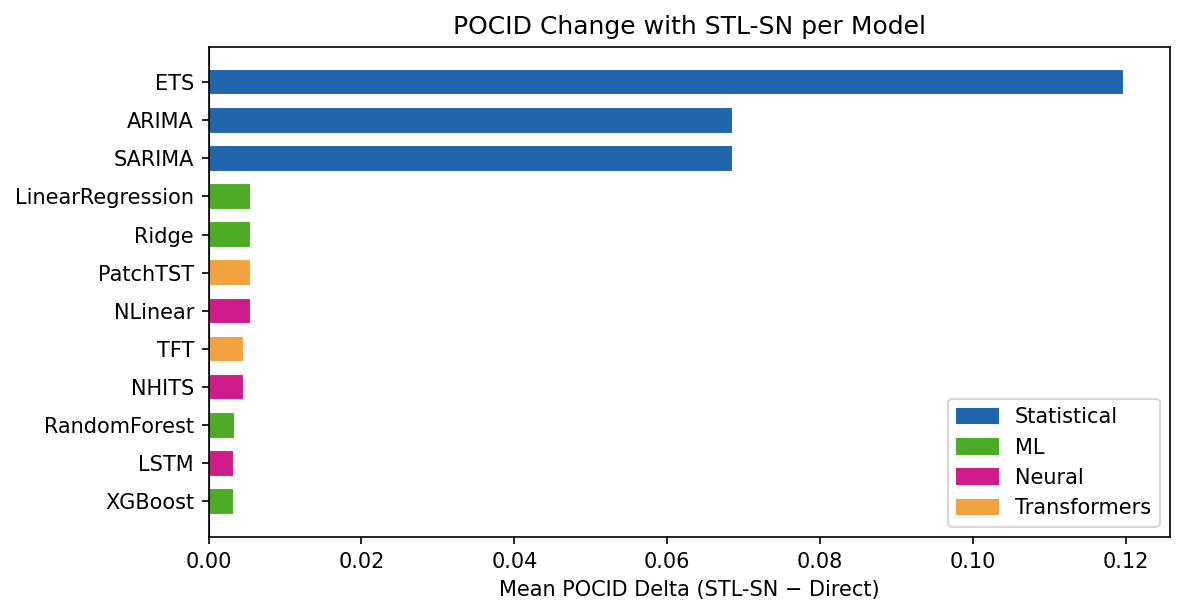

saved fig_pocid_ranking_tuned.png


In [16]:
# POCID ranking: which models improve directional accuracy most with STL-SN?
pocid_model_sorted = pocid_model.sort_values('pocid_delta', ascending=True)
pocid_model_sorted['label'] = pocid_model_sorted['model_name'].str.replace('Auto', '', regex=False)
colors_pocid = pocid_model_sorted['model_family'].map(FAM_COLORS)

fig, ax = plt.subplots(figsize=(8, max(4, len(pocid_model_sorted) * 0.35)))
ax.barh(pocid_model_sorted['label'], pocid_model_sorted['pocid_delta'],
        color=colors_pocid, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Mean POCID Delta (STL-SN − Direct)')
ax.set_title('POCID Change with STL-SN per Model')
patches = [mpatches.Patch(color=FAM_COLORS[f], label=FAM_LABELS[f]) for f in FAM_ORDER]
ax.legend(handles=patches)
fig.tight_layout()
fig.savefig(FIG / 'fig_pocid_ranking_tuned.png', dpi=150)
plt.show()
print('saved fig_pocid_ranking_tuned.png')

---
## 7  STL-AC vs STL-SN — When Does Full Component Modelling Add Value?

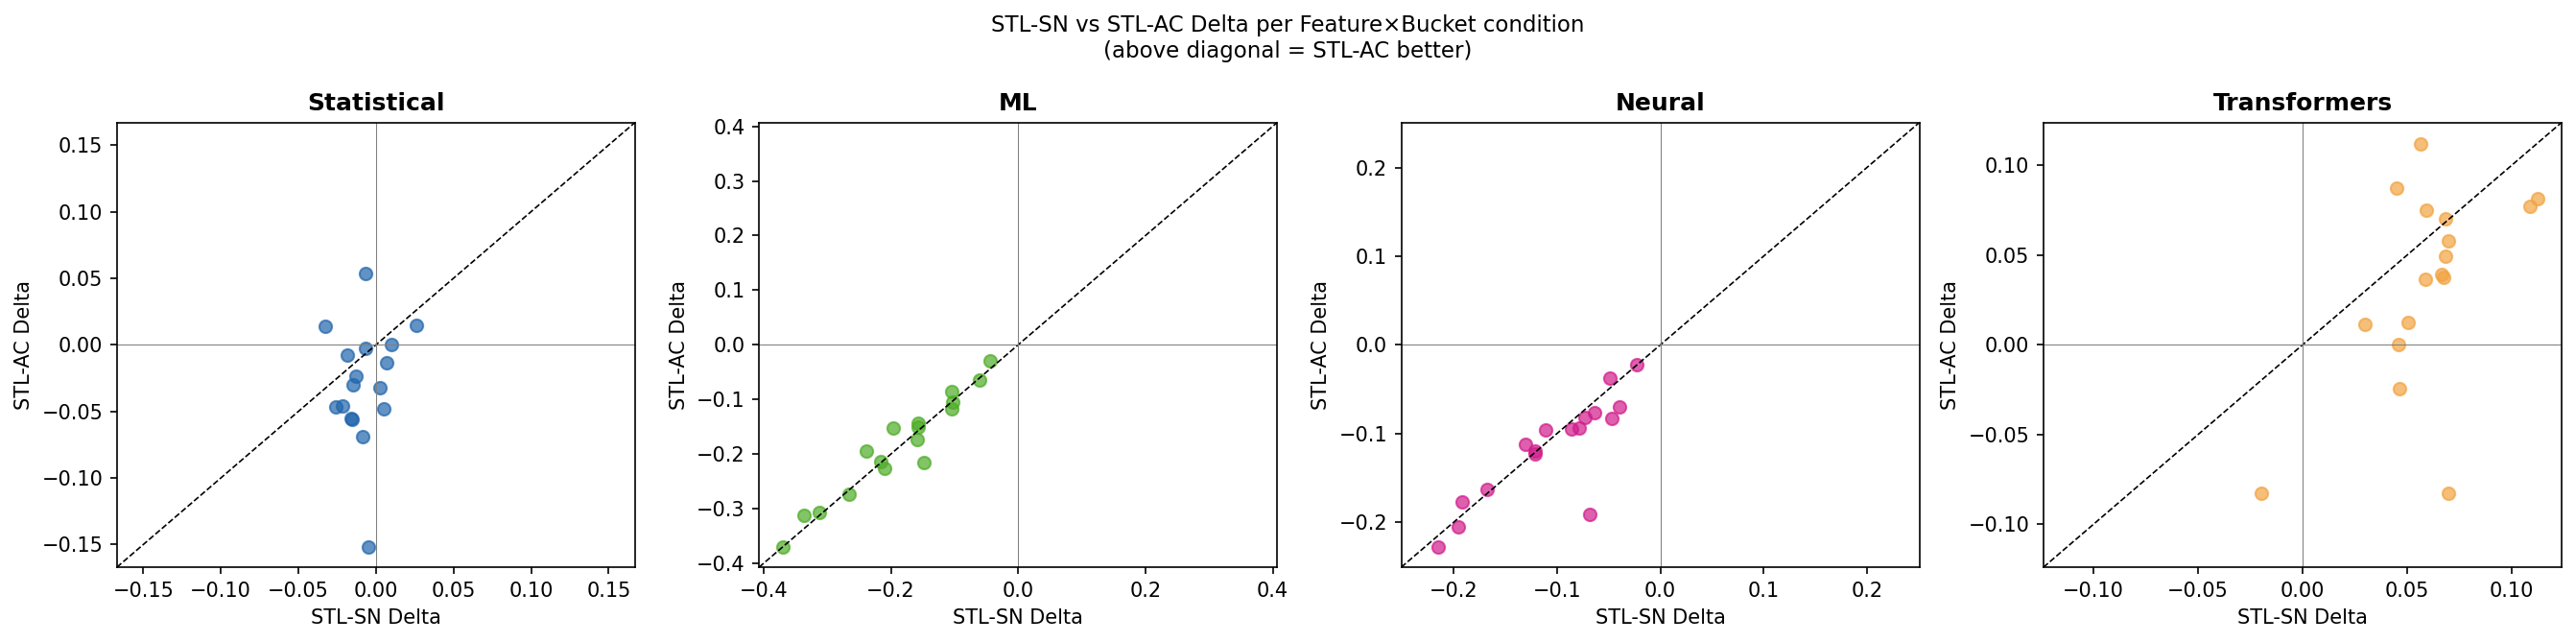

saved fig_sn_vs_ac.png


In [17]:
# Compare STL-SN delta vs STL-AC delta per (family × bucket × feature)
delta_both = (
    base.groupby(['feature_name', 'feature_bucket', 'model_family', 'decomposition_method'])['rn_delta']
    .mean()
    .reset_index()
)
delta_both['decomp_label'] = delta_both['decomposition_method'].map(DECOMP_LABELS)
delta_both = delta_both[delta_both['decomposition_method'] != 'without_stl']  # drop baseline

# for each family, scatter STL-SN vs STL-AC delta across feature×bucket
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, fam in zip(axes, FAM_ORDER):
    sub = delta_both[delta_both['model_family'] == fam]
    sn  = sub[sub['decomposition_method'] == 'stl_seasonal_naive'].set_index(['feature_name','feature_bucket'])['rn_delta']
    ac  = sub[sub['decomposition_method'] == 'stl_model_all_components'].set_index(['feature_name','feature_bucket'])['rn_delta']
    common = sn.index.intersection(ac.index)
    ax.scatter(sn.loc[common], ac.loc[common], alpha=0.7, color=FAM_COLORS[fam], s=40)
    lim = max(abs(sn.loc[common]).max(), abs(ac.loc[common]).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8, label='y=x')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_title(FAM_LABELS[fam], fontweight='bold')
    ax.set_xlabel('STL-SN Delta')
    ax.set_ylabel('STL-AC Delta')

fig.suptitle('STL-SN vs STL-AC Delta per Feature×Bucket condition\n(above diagonal = STL-AC better)', fontsize=11)
fig.tight_layout()
fig.savefig(FIG / 'fig_sn_vs_ac.png', dpi=150)
plt.show()
print('saved fig_sn_vs_ac.png')

---
## 8  Routing Rules — Decision Table

Based on the evidence above, we derive a concise decision table: for a given (model family, feature regime), which decomposition strategy is recommended?

In [18]:
# Best decomp per (feature_name, feature_bucket, model_family)
# using mean delta: best = max (most positive = most helpful)
all_deltas = (
    base.groupby(['feature_name', 'feature_bucket', 'model_family', 'decomposition_method'])['rn_delta']
    .mean()
    .reset_index()
)
best_decomp = (
    all_deltas.loc[all_deltas.groupby(['feature_name','feature_bucket','model_family'])['rn_delta'].idxmax()]
    .reset_index(drop=True)
)
best_decomp['decomp_label'] = best_decomp['decomposition_method'].map(DECOMP_LABELS)
best_decomp['feat_label']   = best_decomp['feature_name'].map(FEATURE_LABELS)

# pivot: rows = feature×bucket, cols = family
routing = best_decomp.pivot_table(
    index=['feat_label', 'feature_bucket'],
    columns='model_family',
    values='decomp_label',
    aggfunc='first',
).reset_index()
routing.columns.name = None
routing = routing.rename(columns={f: FAM_LABELS[f] for f in FAM_ORDER if f in routing.columns})
print('Routing Table — Recommended Decomposition:')
print(routing.to_string(index=False))

Routing Table — Recommended Decomposition:
          feat_label feature_bucket     ML Neural Statistical Transformers
           ARCH Stat           High STL-AC STL-AC      STL-AC       STL-AC
           ARCH Stat            Low STL-SN STL-SN      STL-SN       STL-SN
           ARCH Stat         Medium STL-AC STL-SN      STL-SN       STL-SN
Evolving Seasonality           High STL-AC STL-AC      STL-AC       STL-AC
Evolving Seasonality            Low STL-SN STL-SN      STL-SN       STL-SN
Evolving Seasonality         Medium STL-AC STL-AC      STL-AC       STL-AC
       Non-Normality           High STL-AC STL-SN      STL-SN       STL-SN
       Non-Normality            Low STL-AC STL-AC      STL-AC       STL-AC
       Non-Normality         Medium STL-AC STL-SN      STL-SN       STL-SN
        Nonlinearity           High STL-SN STL-SN      STL-SN       STL-SN
        Nonlinearity            Low STL-AC STL-SN      STL-SN       STL-SN
    Spectral Entropy           High STL-AC STL-AC      ST

In [19]:
# Save routing table as CSV
routing.to_csv(DATA / 'routing_rules.csv', index=False)
print('saved routing_rules.csv')

# Save wilcoxon per model table as CSV
wdf[['model_family','model_name','decomp_label','n','mean_delta','median_delta','pct_helped','p_raw','p_adj','sig','verdict']].to_csv(
    DATA / 'wilcoxon_model_verdicts.csv', index=False
)
print('saved wilcoxon_model_verdicts.csv')

# Save per feature×bucket×family significance table
wdf2[['feature_name','feature_bucket','model_family','n','mean_delta','p_raw','p_adj','sig','verdict']].to_csv(
    DATA / 'wilcoxon_feature_bucket.csv', index=False
)
print('saved wilcoxon_feature_bucket.csv')

saved routing_rules.csv
saved wilcoxon_model_verdicts.csv
saved wilcoxon_feature_bucket.csv


---
## 9  Summary of Findings

### Key Research Conclusions

#### 9.1 Model Family Level
| Family | Best Decomp | Interpretation |
|--------|------------|----------------|
| **Statistical** | Direct | Statistical models (ARIMA, ETS) already model seasonality internally; STL pre-processing redundantly decomposes structure the model handles natively, hurting performance |
| **ML** | STL-AC | Tree-based models benefit greatly from removing trend/seasonal structure — they forecast the residuals and components independently, which are each simpler than the raw series |
| **Neural** | STL-SN | RNNs/NBEATS/NHITS benefit from seasonal isolation (STL-SN); full component modelling (STL-AC) over-fragments the learning signal |
| **Transformers** | STL-SN | Attention mechanisms align well with de-trended series; seasonal naïve handles the seasonal component reliably |

#### 9.2 Model Confidence
- **Always Helps with STL-SN** (Wilcoxon significant, Holm corrected): NLinear, RandomForest, LSTM, XGBoost, TFT, PatchTST, NHITS
- **Always Hurts with STL-SN**: AutoETS, AutoARIMA, AutoSARIMA — statistical models' internal seasonal modelling is disrupted

#### 9.3 Feature-Regime Conditions
| Feature | Low Bucket | High Bucket | Interpretation |
|---------|-----------|------------|----------------|
| **Evolving Seasonality** | Large STL benefit | STL hurts | When seasonality is unstable, STL's fixed seasonal estimate misleads the model at high levels |
| **Non-Normality** | Moderate benefit | Large benefit | More non-normal residuals = more benefit from separating the seasonal component |
| **Nonlinearity** | Moderate benefit | Large benefit | Nonlinear series benefit from STL linearising the components independently |
| **ARCH Stat** | Large benefit | STL hurts | High conditional heteroskedasticity makes the STL seasonal estimate unreliable |
| **Structural Break** | Large benefit | Small/no benefit | STL helps most when series are structurally stable |
| **Spectral Entropy** | Moderate | Peak at Medium | Very noisy series (high entropy) get less benefit from decomposition |

#### 9.4 Routing Rules (Evidence-Based)
- Use **Direct** for: Statistical models (always), high-ARCH / high-evolving-seasonality + neural/transformer
- Use **STL-SN** for: Neural and Transformer models + low-to-medium ARCH/evolving-seasonality
- Use **STL-AC** for: ML models regardless of feature regime; Neural + low-spectral-entropy

#### 9.5 Research Novelty
Prior work on STL decomposition in forecasting typically reports unconditional average improvement. This work demonstrates that **the benefit of STL decomposition is strongly conditional on**:
1. The model family (family-specific seasonal handling)
2. The degree of evolving seasonality (stable vs unstable seasonal patterns)
3. Residual heteroskedasticity (ARCH effects)
4. Non-normality and nonlinearity of the series

This provides a **feature-based routing framework** for practitioners to select decomposition strategy without trial-and-error.